In [ ]:
import torch

# si ringrazia la gentile partecipazione del server Linux per la generazione del dataset (METIS non funziona su Windows)
#dataset = RedditSubGraphDataset(path='Reddit', num_graphs=1000, task_type='a')

dataset = torch.load("reddit_task3_clusters_a.pt", weights_only=False)
# classe 1: sopra media = 370 grafi
# classe 0: sotto media = 630 grafi

In [7]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(dataset["train"], batch_size=128, shuffle=True)
val_loader = DataLoader(dataset["val"], batch_size=128, shuffle=False)
test_loader = DataLoader(dataset["test"], batch_size=128, shuffle=False)

In [ ]:
from utils_task3_a import HierarchicalGCNClassifier,train_loop,evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classi = 2
lr=5e-4
epochs = 50

model = HierarchicalGCNClassifier(in_channels=dataset['train'][0].num_features, 
                                  hidden_channels=256, 
                                  out_channels=1).to(device)

bce_weight = torch.tensor([630/370],dtype=torch.float32).to(device) #indica il rapporto tra le classi
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=bce_weight)
best_model_path="best_model_task3_GCN.pth"
scaler = torch.amp.GradScaler()

history = train_loop(model,train_loader,val_loader,optimizer,loss_fn,device,epochs,best_model_path,scaler)

Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 18.34it/s]


Epoch 1/50 - Train Loss: 0.8646 - Val Loss: 0.8507 - Balanced Accuracy: 0.5000 - F1 Score: 0.4870
Nuovo miglior modello salvato con Val Loss: 0.8507
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 23.01it/s]


Epoch 2/50 - Train Loss: 0.8592 - Val Loss: 0.8272 - Balanced Accuracy: 0.5000 - F1 Score: 0.4870
Nuovo miglior modello salvato con Val Loss: 0.8272
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 20.35it/s]


...

Epoch 20/50 - Train Loss: 0.2370 - Val Loss: 0.4599 - Balanced Accuracy: 0.8634 - F1 Score: 0.8703
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 20.04it/s]


Epoch 21/50 - Train Loss: 0.1836 - Val Loss: 0.4967 - Balanced Accuracy: 0.8610 - F1 Score: 0.8613
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 1/1 [00:00<00:00, 18.66it/s]

Epoch 22/50 - Train Loss: 0.1537 - Val Loss: 0.4695 - Balanced Accuracy: 0.8554 - F1 Score: 0.8607
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


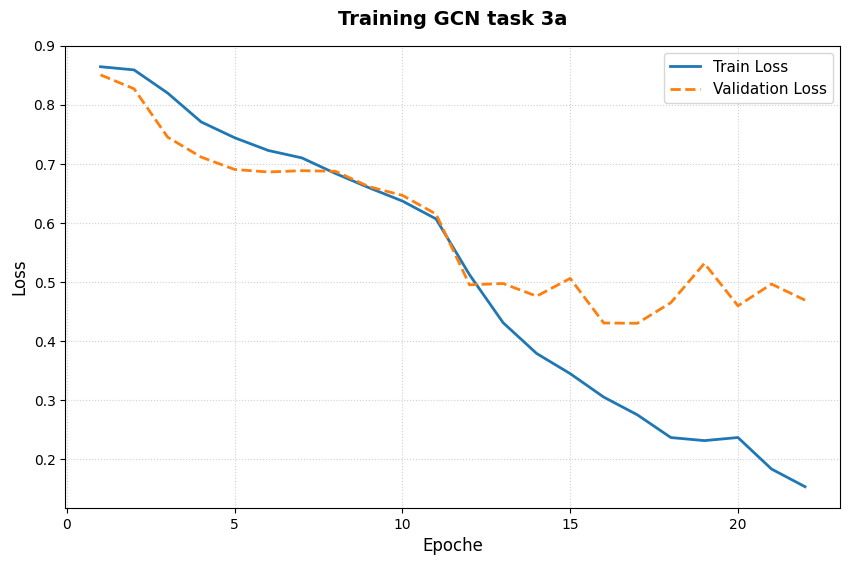

In [ ]:
from utils_task3_a import plot_history

plot_history(history,"Training GCN task 3a")

In [19]:
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")


Valutazione sul test set


Evaluating...: 100%|██████████| 1/1 [00:00<00:00,  4.41it/s]

Test Loss: 0.2904 - Balanced Accuracy: 0.8769 - F1 Score: 0.8806
